# Analysis of QRC-ESN vs. Classical ESN Results

### **Notebook Objective**

This notebook analyzes the results generated by `01_run_experiments.ipynb`. Its purpose is to load the saved experimental data, identify the best-performing models, and visualize their performance without re-running any of the computationally expensive training processes.

### **Process**
1.  **Load Data**: Import the results from the `.csv` file.
2.  **Comparative Analysis**: Find the best hyperparameters for both QRC and Classical ESN models for each data profile based on the median Mean Squared Error (MSE).
3.  **Display Summaries**: Present the findings in clear, comparative tables.
4.  **Visualize**: (Placeholder) Generate plots to visually compare the performance of the best models on the time series data.

In [1]:
# === IMPORTS AND SETUP ===
import sys
import os

project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Import our custom modules
from src.data_generation import mackey_glass, generate_arma_data, generate_narma_data
from src.visualization import plot_best_model_comparison, plot_train_val_test_overview

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Jupyter magic command for automatic reloading of external modules
%load_ext autoreload
%autoreload 2

# Pandas display options for better table formatting
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

print("Libraries and modules loaded successfully.")

Libraries and modules loaded successfully.


In [2]:
# === LOAD RESULTS DATA ===

RESULTS_FILENAME = '../data/results_comparative.csv'

try:
    results_df = pd.read_csv(RESULTS_FILENAME)
    print(f"Successfully loaded {len(results_df)} results from '{RESULTS_FILENAME}'.")
except FileNotFoundError:
    print(f"ERROR: The results file '{RESULTS_FILENAME}' was not found.")
    print("Please run the '01_run_experiments.ipynb' notebook first to generate the results.")
    results_df = pd.DataFrame() # Create an empty DataFrame to prevent errors in subsequent cells

# Display a sample of the loaded data
if not results_df.empty:
    results_df.head()

Successfully loaded 1080 results from '../data/results_comparative.csv'.


In [3]:
# === COMPARATIVE ANALYSIS ===
# Hyperparameter selection is performed on the validation set (median_val_mse).
# The reported performance comes from the held-out test set (median_test_mse).

comparison_summary = []

if not results_df.empty:
    for profile_name in results_df['data_profile'].unique():
        profile_df = results_df[results_df['data_profile'] == profile_name]

        qrc_df = profile_df[profile_df['model_type'] == 'QRC'].dropna(subset=['median_val_mse'])
        classical_df = profile_df[profile_df['model_type'] == 'Classical_ESN'].dropna(subset=['median_val_mse'])

        if qrc_df.empty or classical_df.empty:
            print(f"--> INFO: Skipping profile '{profile_name}' due to missing results for one or both models.")
            continue

        best_qrc_row = qrc_df.loc[qrc_df['median_val_mse'].idxmin()]
        best_classical_row = classical_df.loc[classical_df['median_val_mse'].idxmin()]

        summary = {
            'Data Profile': profile_name,
            'QRC Val MSE': best_qrc_row['median_val_mse'],
            'QRC Test MSE': best_qrc_row['median_test_mse'],
            'Classical Val MSE': best_classical_row['median_val_mse'],
            'Classical Test MSE': best_classical_row['median_test_mse'],
            'QRC Stability (CV test)': best_qrc_row['cv_test_mse'],
            'Classical Stability (CV test)': best_classical_row['cv_test_mse']
        }
        comparison_summary.append(summary)

if comparison_summary:
    summary_df = pd.DataFrame(comparison_summary)
    print("--- Best Model Comparison (selected by val MSE, reported on test MSE) ---")
    print(summary_df.to_string(index=False))
else:
    print("\nNo valid results found to generate a comparison summary.")

--- Best Model Comparison (selected by val MSE, reported on test MSE) ---
          Data Profile  QRC Val MSE  QRC Test MSE  Classical Val MSE  Classical Test MSE  QRC Stability (CV test)  Classical Stability (CV test)
 Mackey_Glass_(tau=17)     0.000003      0.000003       2.738589e-08        2.447642e-08                 2.976513                       0.128176
 Mackey_Glass_(tau=30)     0.000004      0.000003       6.042390e-08        6.242187e-08                 2.014229                       0.059450
Mackey_Glass_(tau=100)     0.000004      0.000007       1.322826e-07        3.715181e-07                 1.622457                       0.107450
   ARMA_1_2_stochastic     0.008743      0.008003       8.452196e-03        7.919477e-03                 0.010328                       0.019600
       NARMA10_Chaotic     0.008379      0.009055       7.842597e-03        8.319603e-03                 0.012422                       0.016026
        NARMA5_Chaotic     0.012809      0.012176       

In [4]:
# === DETAILED HYPERPARAMETERS OF BEST MODELS ===
# Best configuration per (profile, model) is chosen by lowest median_val_mse.

if not results_df.empty:
    valid_results_df = results_df.dropna(subset=['median_val_mse'])

    best_models_df = valid_results_df.loc[
        valid_results_df.groupby(['data_profile', 'model_type'])['median_val_mse'].idxmin()
    ]

    if not best_models_df.empty:
        print("\n--- Detailed Hyperparameters of Best Models (by Val MSE) ---")
        print(best_models_df.sort_values(by=['data_profile', 'model_type']).to_string())
    else:
        print("Could not determine the best models.")


--- Detailed Hyperparameters of Best Models (by Val MSE) ---
         model_type            data_profile  median_val_mse   std_val_mse  cv_val_mse  median_test_mse  std_test_mse  cv_test_mse  leakage_rate    lambda_reg  window_size  n_layers  lag  base_seed  reservoir_size  spectral_radius  sparsity
644   Classical_ESN     ARMA_1_2_stochastic    8.452196e-03  1.414776e-04    0.016739     7.919477e-03  1.552220e-04     0.019600           0.9  1.000000e-08           10       NaN  NaN       2025            50.0              1.1       0.1
553             QRC     ARMA_1_2_stochastic    8.742718e-03  1.601071e-04    0.018313     8.003038e-03  8.265635e-05     0.010328           0.1  1.000000e-08            8       2.0  0.0       2025             NaN              NaN       NaN
484   Classical_ESN  Mackey_Glass_(tau=100)    1.322826e-07  1.944886e-08    0.147025     3.715181e-07  3.991949e-08     0.107450           0.9  1.000000e-08           10       NaN  NaN       2025           100.0      


--- Generating plot for profile: Mackey_Glass_(tau=17) ---

Retraining best QRC model...
Best QRC Median Test MSE: 0.000003
Retraining best Classical ESN model...
Best Classical ESN Median Test MSE: 0.000000


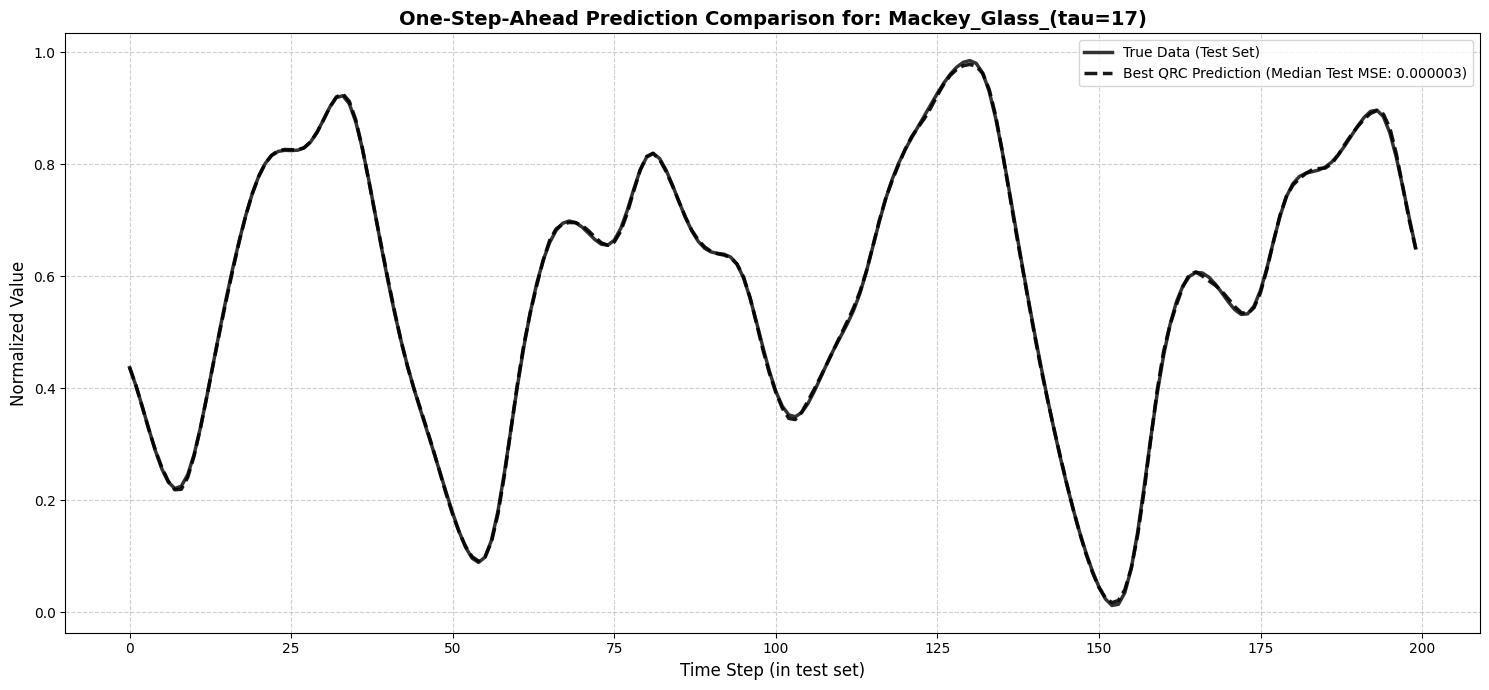


--- Generating plot for profile: Mackey_Glass_(tau=30) ---

Retraining best QRC model...
Best QRC Median Test MSE: 0.000003
Retraining best Classical ESN model...
Best Classical ESN Median Test MSE: 0.000000


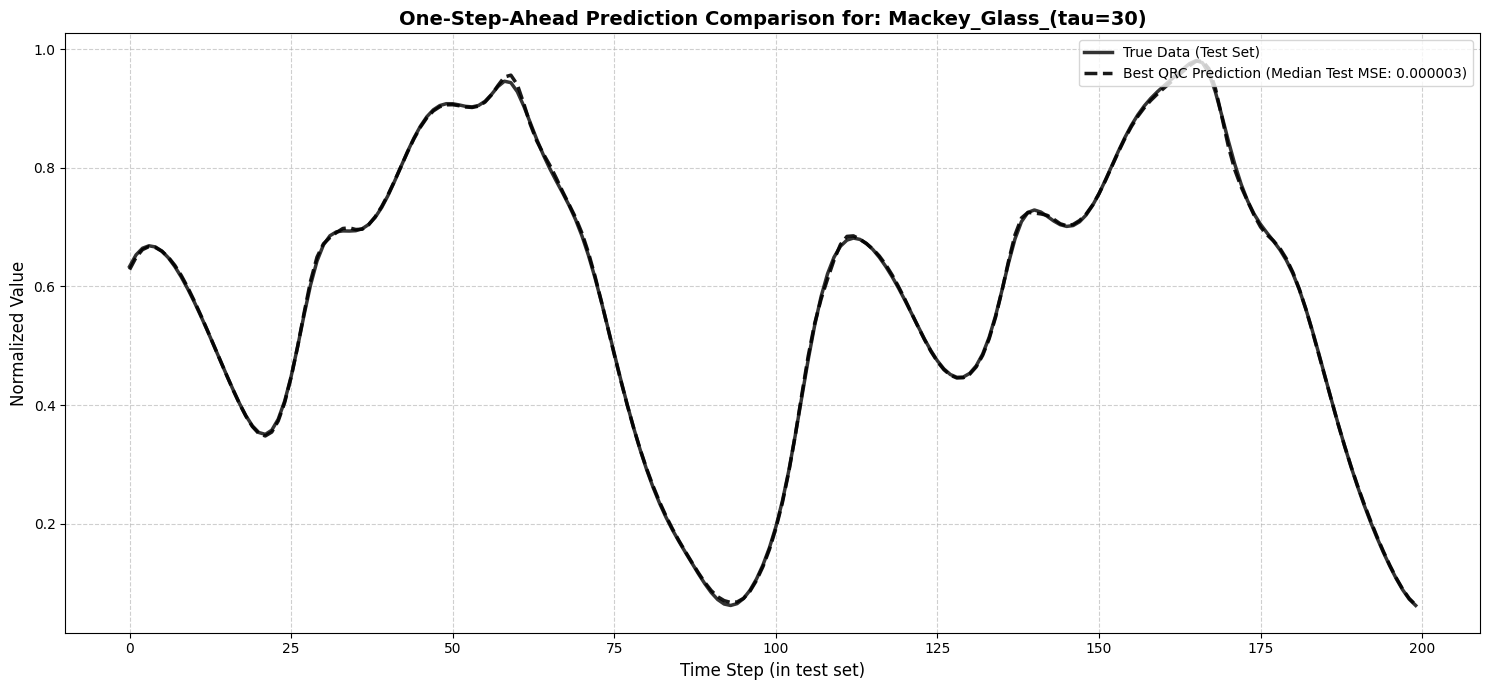


--- Generating plot for profile: Mackey_Glass_(tau=100) ---

Retraining best QRC model...
Best QRC Median Test MSE: 0.000007
Retraining best Classical ESN model...
Best Classical ESN Median Test MSE: 0.000000


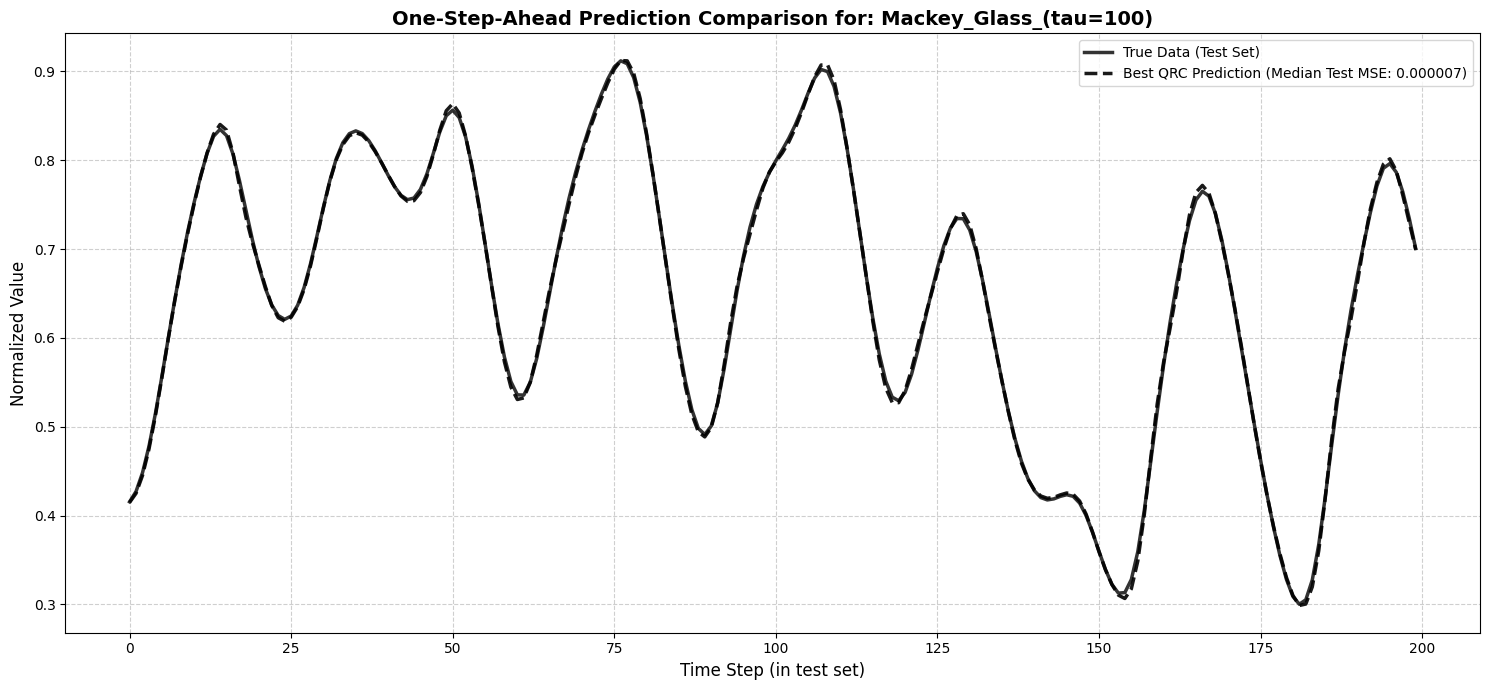


--- Generating plot for profile: ARMA_1_2_stochastic ---

Retraining best QRC model...
Best QRC Median Test MSE: 0.008003
Retraining best Classical ESN model...
Best Classical ESN Median Test MSE: 0.007919


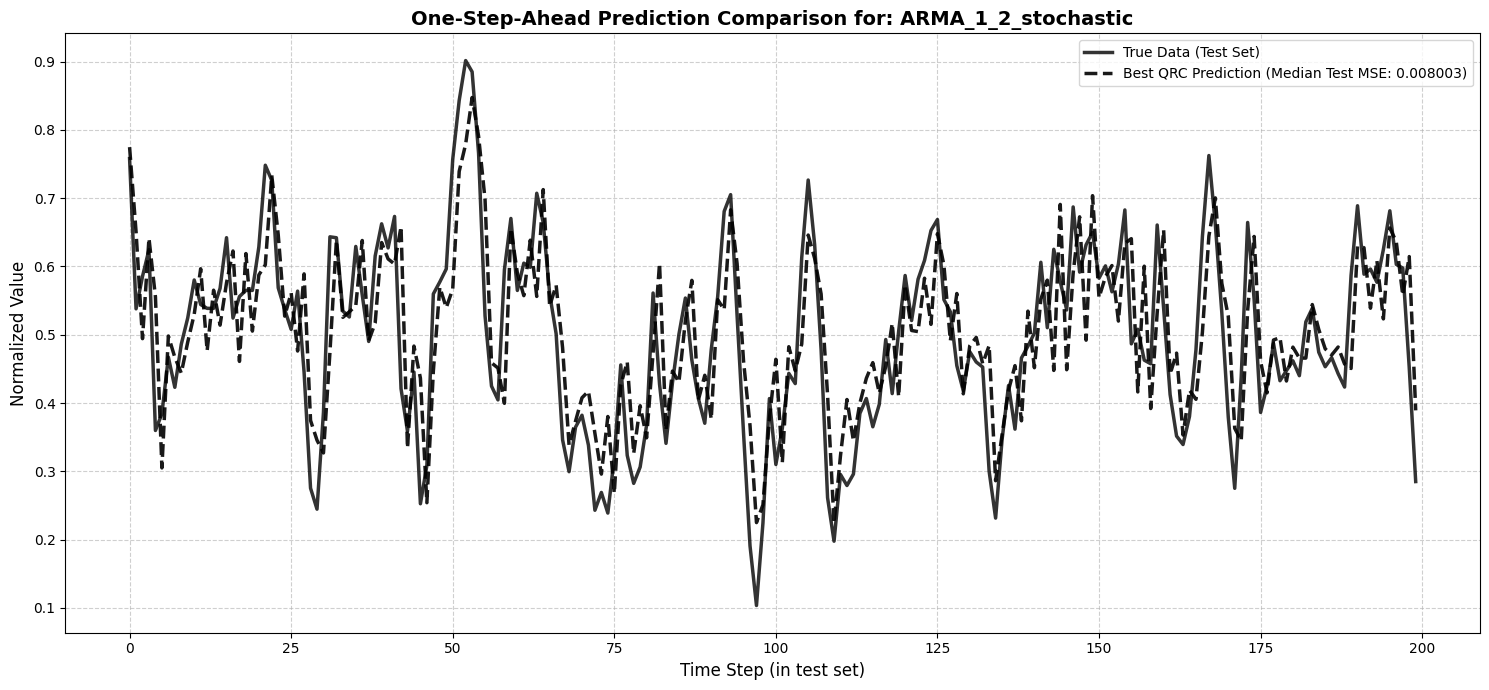


--- Generating plot for profile: NARMA10_Chaotic ---

Retraining best QRC model...
Best QRC Median Test MSE: 0.009055
Retraining best Classical ESN model...
Best Classical ESN Median Test MSE: 0.008320


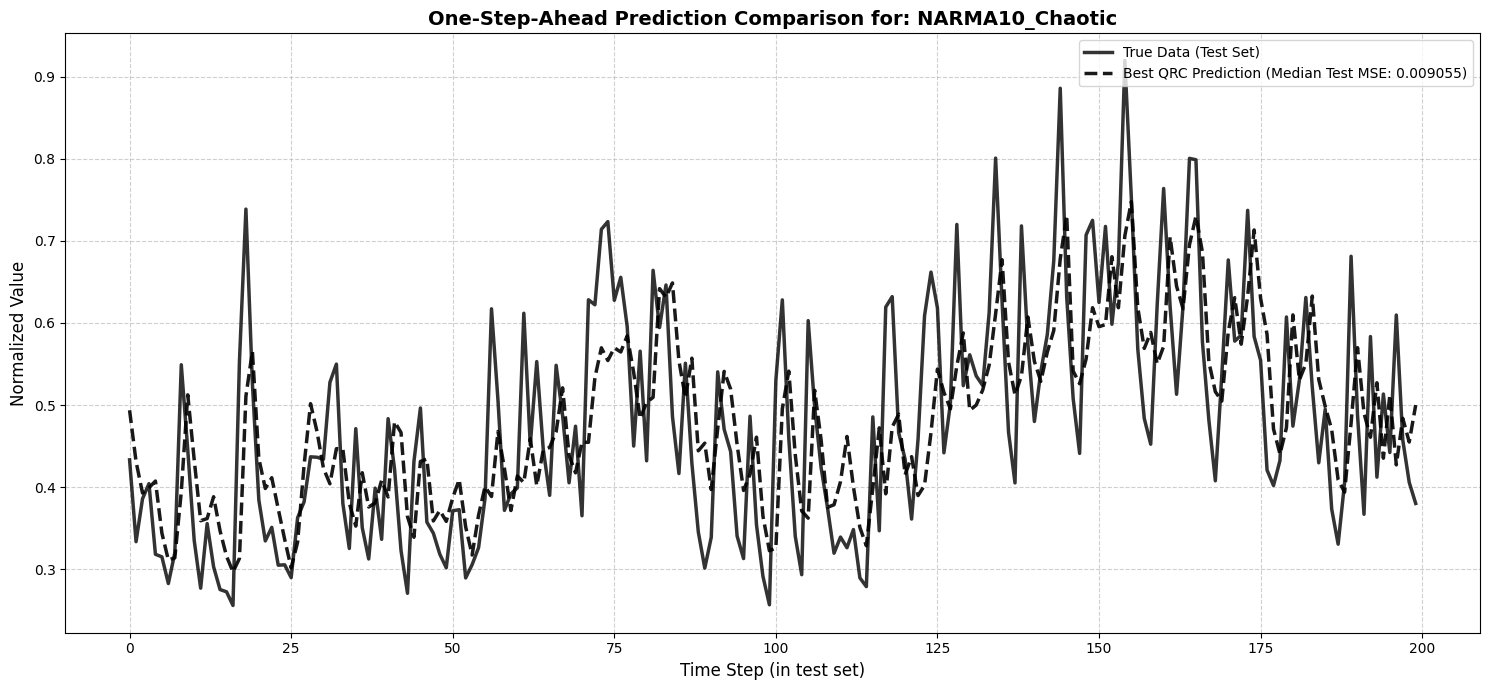


--- Generating plot for profile: NARMA5_Chaotic ---

Retraining best QRC model...
Best QRC Median Test MSE: 0.012176
Retraining best Classical ESN model...
Best Classical ESN Median Test MSE: 0.011440


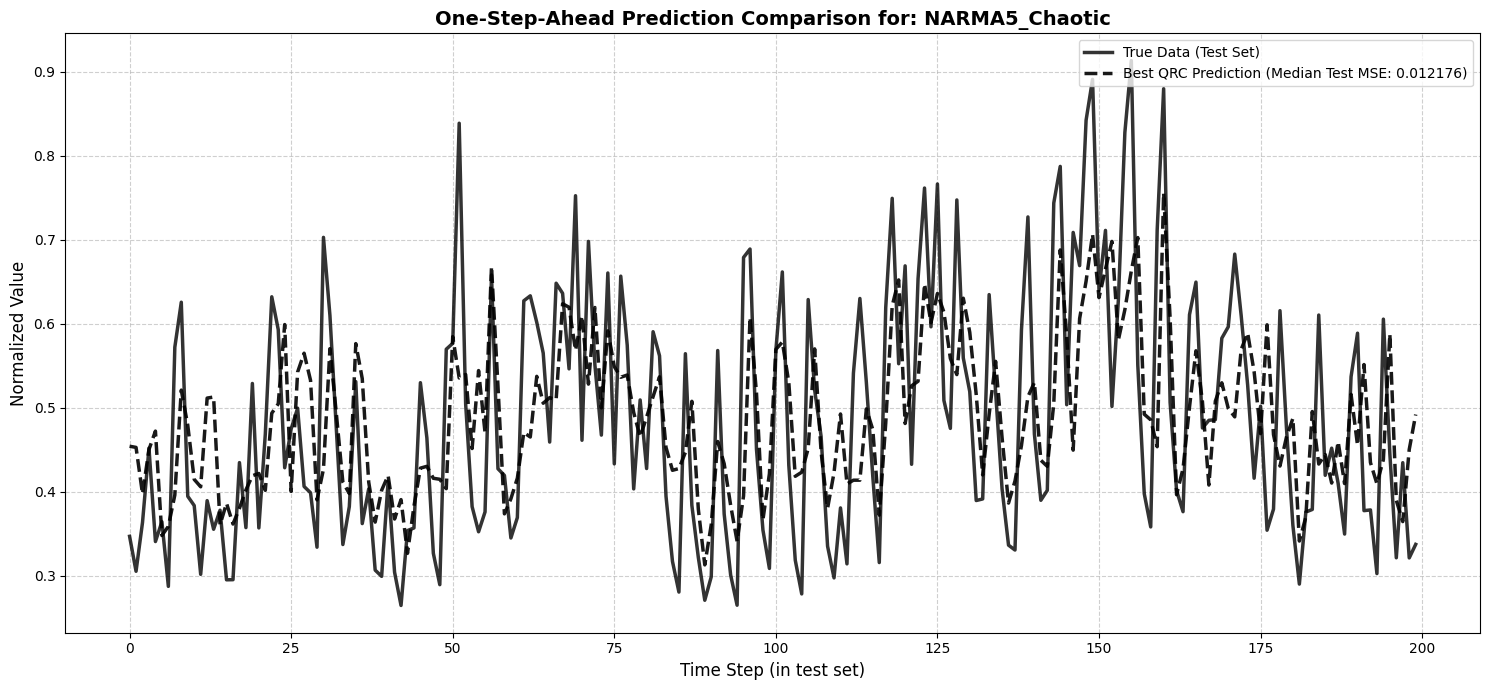

In [5]:
# === VISUALIZE BEST MODEL PERFORMANCE ===

# This cell iterates through each data profile, finds the best performing
# models (by validation MSE), and uses the dedicated plotting function from
# src/visualization.py to generate and display a comparative plot.

# Define constants needed for data regeneration
constants = {
    'TRAIN_FRACTION': 0.6,
    'VAL_FRACTION': 0.2,
    'WASHOUT': 100,
    'SEED': 2025
}

# Define the data profiles again so the visualization module can access them
# This should match the configuration in the experiment runner notebook
data_profiles_config = [
    {'name': 'Mackey_Glass_(tau=17)', 'generator': mackey_glass, 'params': {'tau': 17}},
    {'name': 'Mackey_Glass_(tau=30)', 'generator': mackey_glass, 'params': {'tau': 30}},
    {'name': 'Mackey_Glass_(tau=100)', 'generator': mackey_glass, 'params': {'tau': 100}},
    {'name': 'ARMA_1_2_stochastic', 'generator': generate_arma_data, 'params': {}},
    {'name': 'NARMA10_Chaotic', 'generator': generate_narma_data, 'params': {'order': 10}},
    {'name': 'NARMA5_Chaotic', 'generator': generate_narma_data, 'params': {'order': 5}}
]


if not results_df.empty:
    for profile_config in data_profiles_config:
        profile_name = profile_config['name']

        # Filter results for the current profile
        profile_df = results_df[results_df['data_profile'] == profile_name]

        # Selection is done on validation MSE
        qrc_df = profile_df[profile_df['model_type'] == 'QRC'].dropna(subset=['median_val_mse'])
        classical_df = profile_df[profile_df['model_type'] == 'Classical_ESN'].dropna(subset=['median_val_mse'])

        if qrc_df.empty or classical_df.empty:
            print(f"\n--> SKIPPING PLOT for '{profile_name}' due to missing results.")
            continue

        best_qrc_row = qrc_df.loc[qrc_df['median_val_mse'].idxmin()]
        best_classical_row = classical_df.loc[classical_df['median_val_mse'].idxmin()]

        # Existing one-step-ahead comparison plot (test set)
        plot_best_model_comparison(best_qrc_row, best_classical_row, profile_config, constants)
else:
    print("Results DataFrame is empty. Cannot generate plots.")


--- Generating split overview for profile: Mackey_Glass_(tau=17) ---



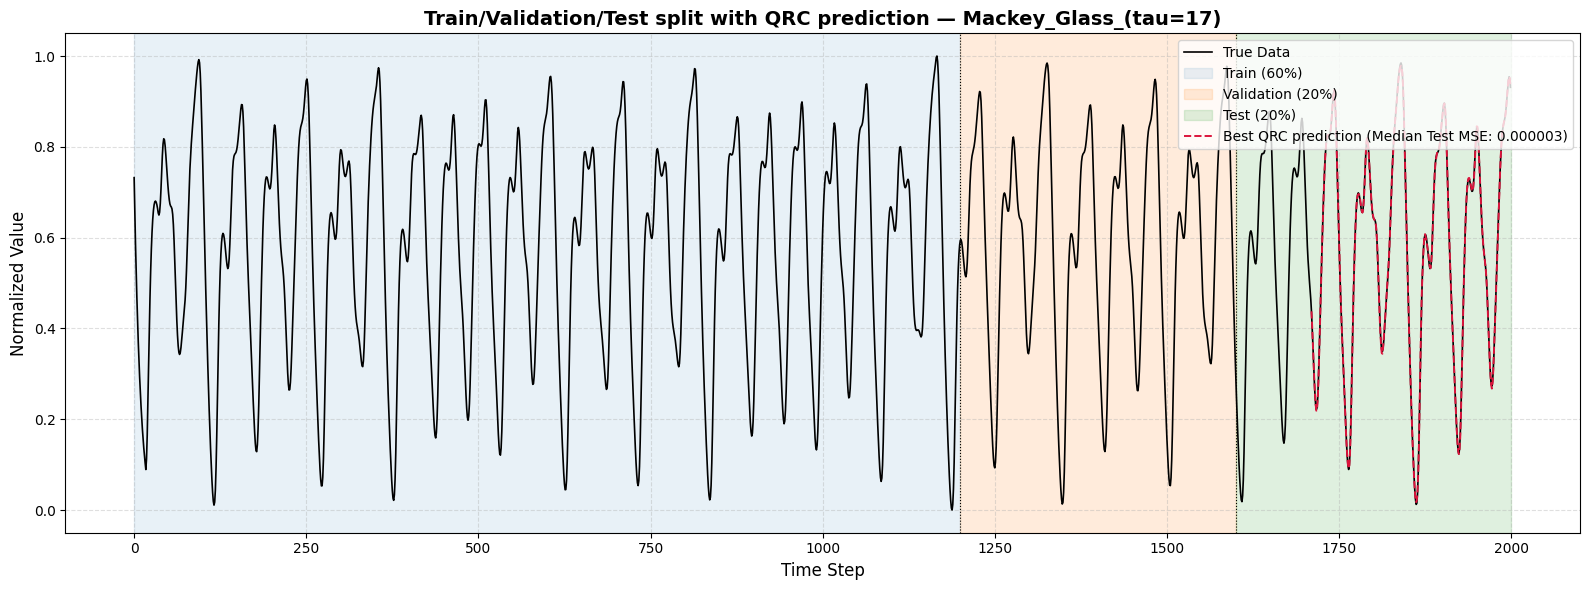


--- Generating split overview for profile: Mackey_Glass_(tau=30) ---



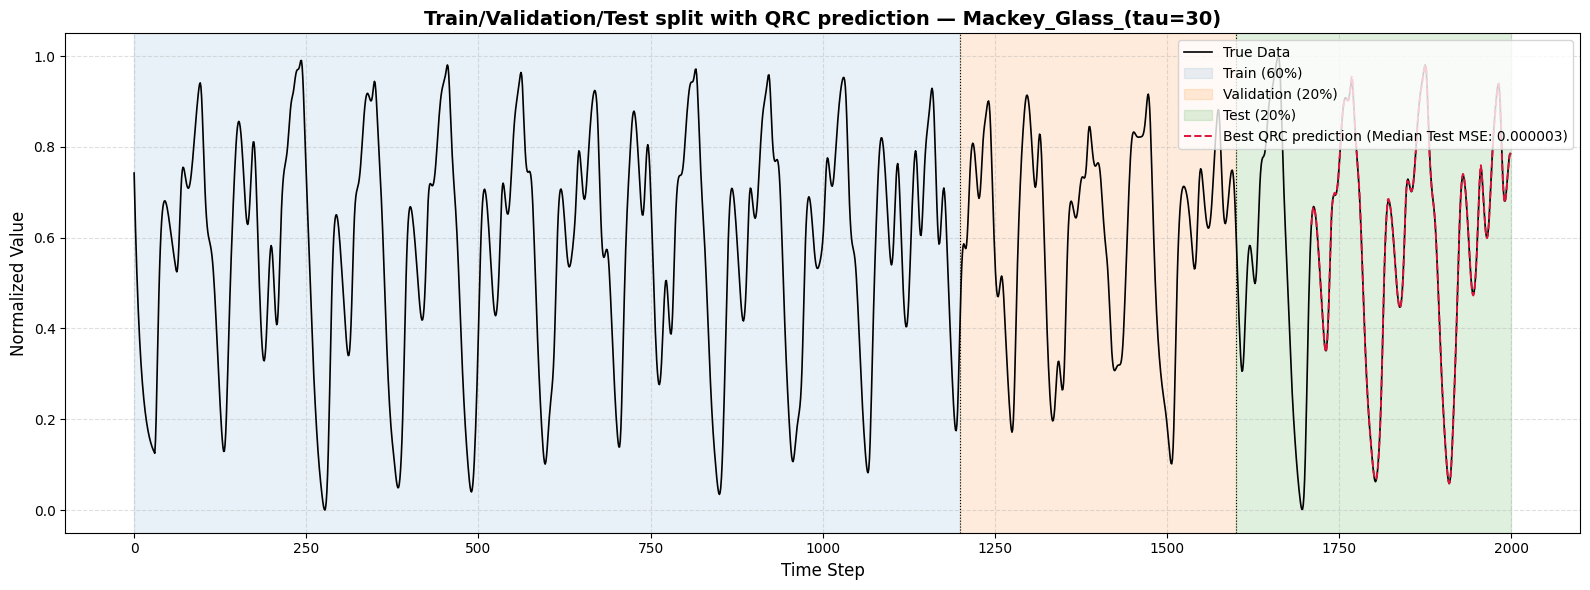


--- Generating split overview for profile: Mackey_Glass_(tau=100) ---



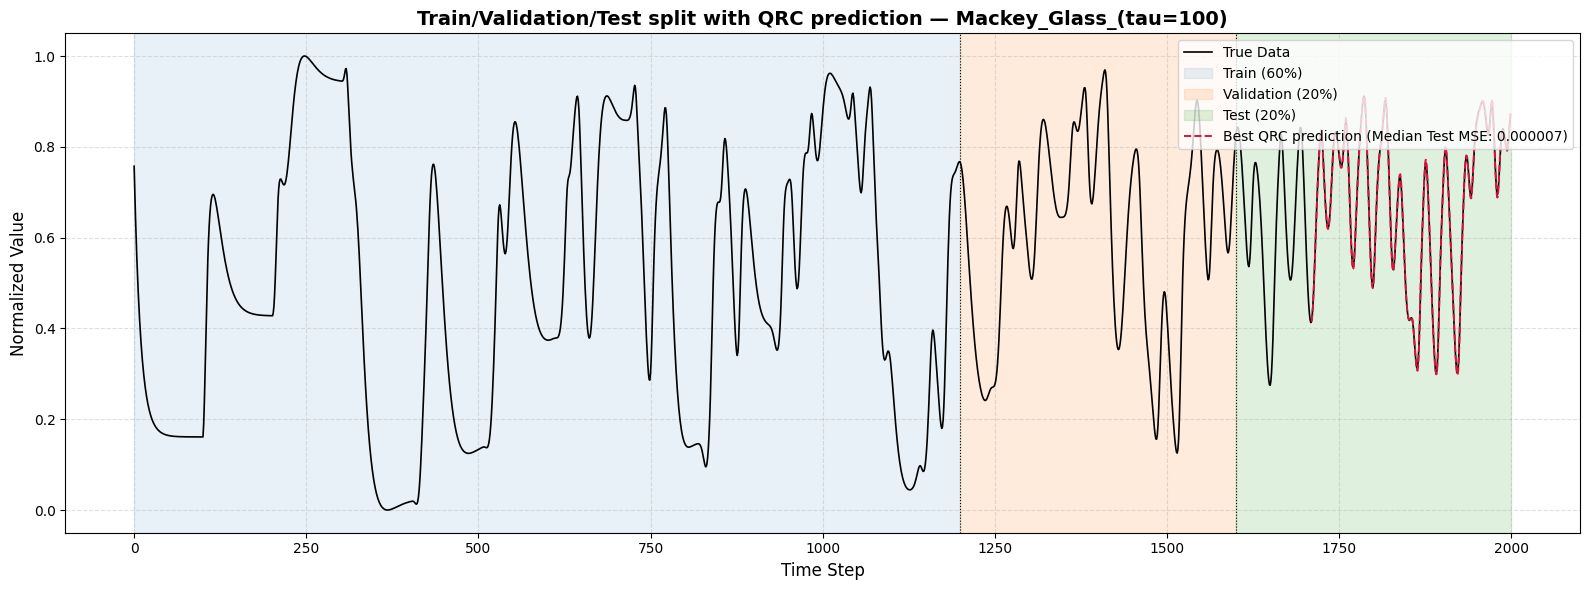


--- Generating split overview for profile: ARMA_1_2_stochastic ---



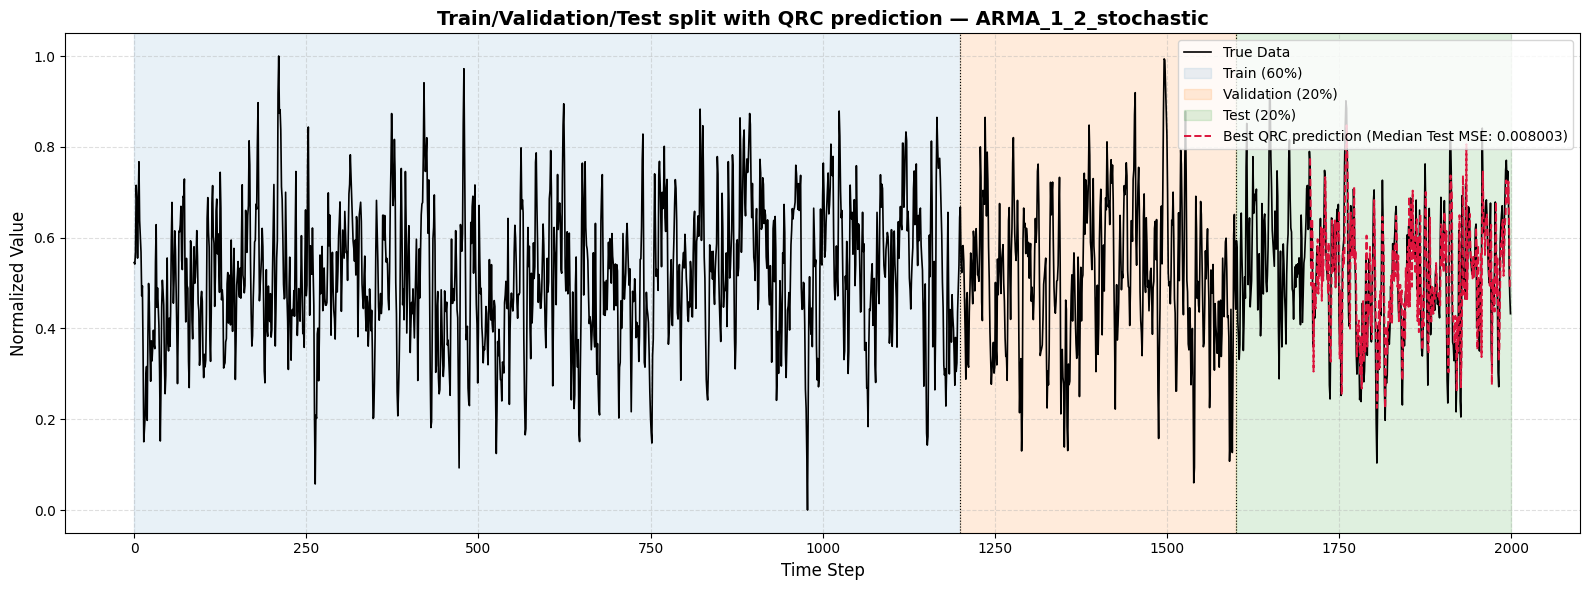


--- Generating split overview for profile: NARMA10_Chaotic ---



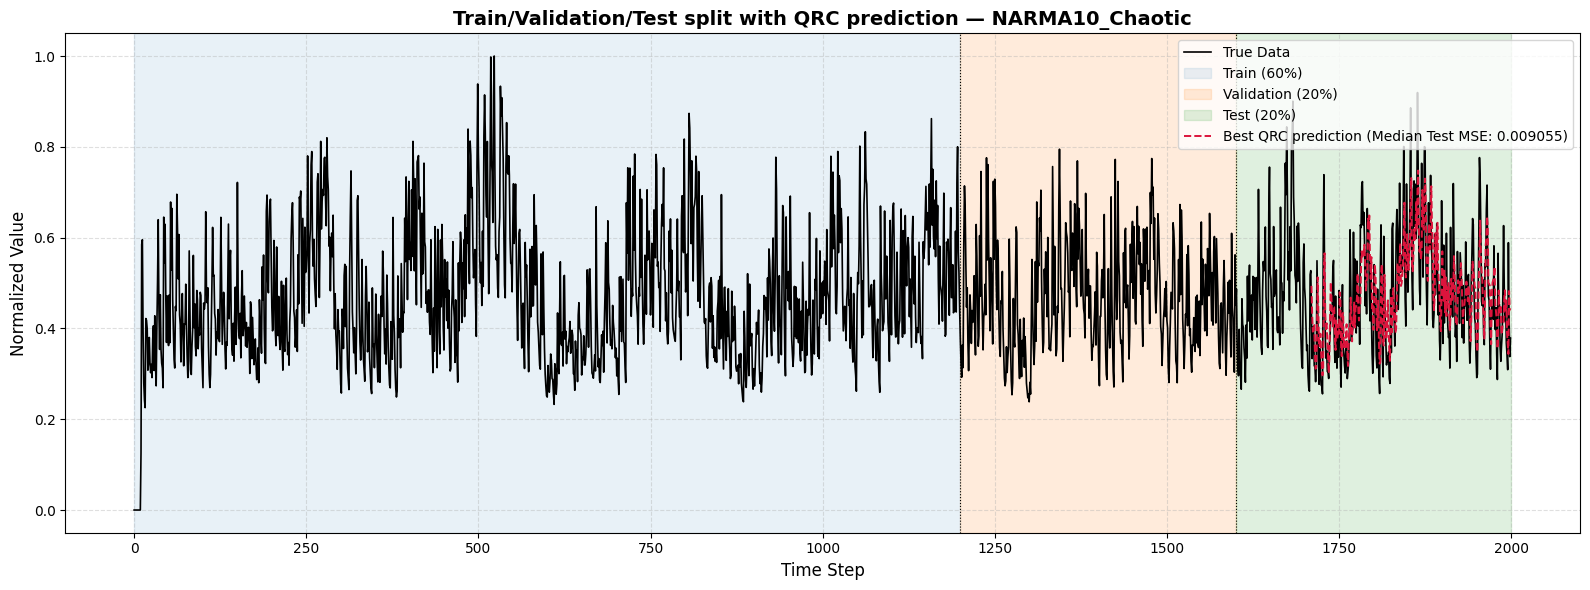


--- Generating split overview for profile: NARMA5_Chaotic ---



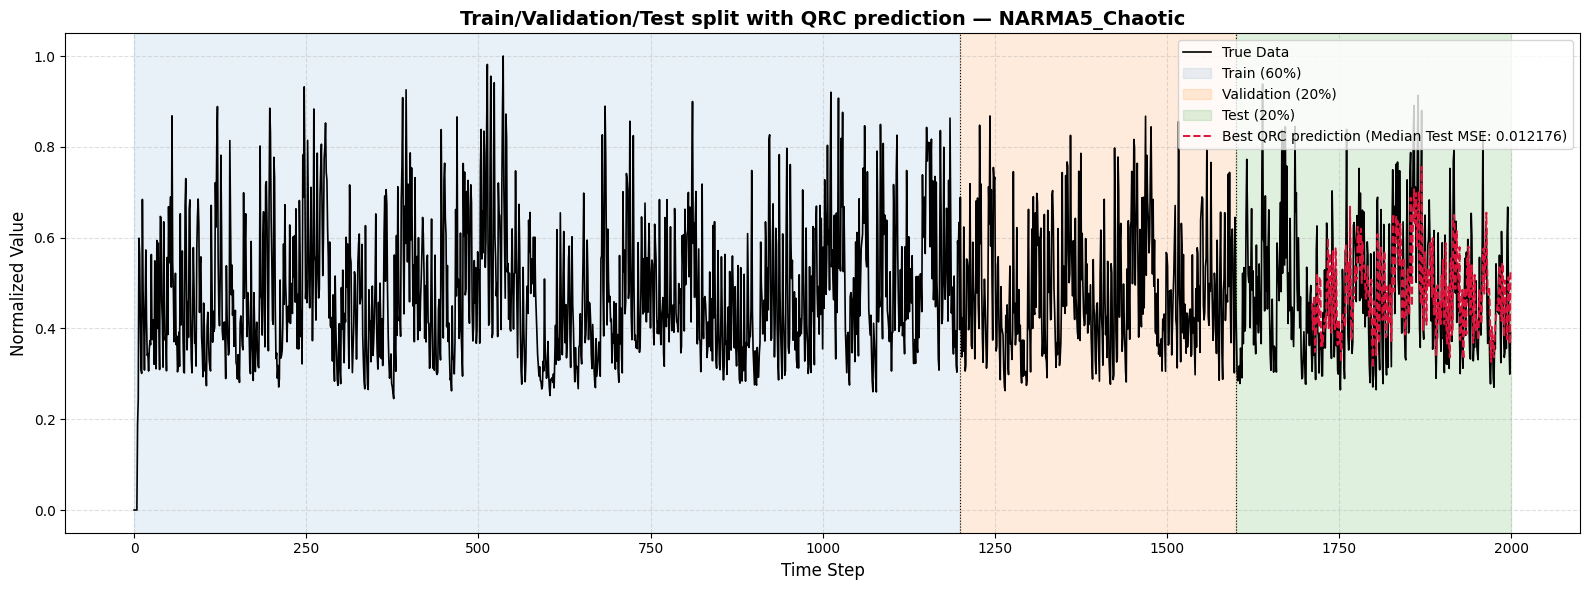

In [6]:
# === TRAIN/VAL/TEST OVERVIEW PLOTS ===
# New visualization: shows the entire time series with shaded train/val/test
# regions and overlays the best QRC prediction on the test segment.

if not results_df.empty:
    for profile_config in data_profiles_config:
        profile_name = profile_config['name']

        profile_df = results_df[results_df['data_profile'] == profile_name]
        qrc_df = profile_df[profile_df['model_type'] == 'QRC'].dropna(subset=['median_val_mse'])

        if qrc_df.empty:
            print(f"\n--> SKIPPING OVERVIEW for '{profile_name}' due to missing QRC results.")
            continue

        best_qrc_row = qrc_df.loc[qrc_df['median_val_mse'].idxmin()]
        plot_train_val_test_overview(best_qrc_row, profile_config, constants)
else:
    print("Results DataFrame is empty. Cannot generate overview plots.")